# Project of Analysis for New lines of Books 

## Introduccion 
El mercado de aplicaciones para lectores ha crecido significativamente en los últimos años, especialmente a raíz de la pandemia, misma situacion que incentivó a más personas a buscar alternativas de entretenimiento en casa. Este proyecto se centra en el análisis de una base de datos real de una plataforma de libros, con el fin de extraer información relevante sobre el comportamiento de los usuarios, la popularidad de los libros y el desempeño de autores y editoriales. Los resultados obtenidos servirán como base para la propuesta de valor de un nuevo producto digital que busca mejorar la experiencia de los usuarios a su vez que potenciar la oferta de la plataforma.

## Objetivo general:

- Analizar la base de datos de la plataforma para identificar tendencias y patrones relevantes que contribuyan al desarrollo de una propuesta de valor para un nuevo producto digital.
### Objetivos específicos:

 - Explorar y comprender la estructura y el contenido de las tablas disponibles en la base de datos.
 - Determinar la cantidad de libros publicados después del 1 de enero de 2000.
 - Calcular el número de reseñas de usuarios y la calificación promedio para cada libro.
 - Identificar la editorial que ha publicado la mayor cantidad de libros con más de 50 páginas.
 - Determinar el autor con la calificación promedio más alta, considerando solo libros con al menos 50 calificaciones.
 - Calcular el número promedio de reseñas de texto entre los usuarios que han calificado más de 50 libros.

## Descripcion de los datos relacionados con el proyecto:
``books:``
Contiene datos sobre libros:

- book_id — identificación del libro
- author_id — identificación del autor o autora
- title — título
- num_pages — número de páginas
- publication_date — fecha de la publicación
- publisher_id — identificación de la editorial

``authors:``
Contiene datos sobre autores:

- author_id — identificación del autor o autora
- author — el autor o la autora

``publishers:``
Contiene datos sobre editoriales:

- publisher_id — identificación de la editorial
- publisher — la editorial

``ratings:``
Contiene datos sobre las calificaciones de usuarios:

- rating_id — identificación de la calificación
- book_id — identificación del libro
- username — el nombre del usuario que revisó el libro
- rating — calificación

``reviews:``
Contiene datos sobre las reseñas de los y las clientes:

- review_id — identificación de la reseña
- book_id — identificación del libro
- username — el nombre del usuario que revisó el libro
- text — el texto de la reseña

In [508]:
# Importacion de librerias
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine


## Conexion a la base de datos SQL

In [509]:
# Establecer la conexión a la base de datos PostgreSQL

db_config = {
 'user': 'practicum_student', # username
 'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7', # password
 'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
 'port': 5432, # connection port
 'db': 'data-analyst-final-project-db' # the name of the database
 }
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(db_config['user'],
                                                         db_config['pwd'],
                                                         db_config['host'],
                                                         db_config['port'],
                                                         db_config['db'])
engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [510]:
# Funcion para obtener los datos de acuerdo a la consulta SQL

def get_data(query):
    with engine.connect() as connection:
        return pd.read_sql(query, connection)

## Analisis Exploratorio de los datos


In [511]:
# Carga de dataset books

books= get_data('SELECT * FROM books')
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_id           1000 non-null   int64 
 1   author_id         1000 non-null   int64 
 2   title             1000 non-null   object
 3   num_pages         1000 non-null   int64 
 4   publication_date  1000 non-null   object
 5   publisher_id      1000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 47.0+ KB


In [512]:
# Muestra de registros aleatorios del dataset
print(books.sample(5))

     book_id  author_id                              title  num_pages  \
321      322        259          Honeymoon (Honeymoon  #1)        406   
302      303        291               Harvesting the Heart        453   
99       100        532                           Birdsong        483   
67        68        369  Alone (Detective D.D. Warren  #1)        451   
626      627        469                      The Alchemist        197   

    publication_date  publisher_id  
321       2007-01-01           116  
302       1995-04-01           212  
99        1997-06-02           315  
67        2005-12-27            35  
626       1993-05-01           133  


In [513]:
# Carga de dataset authors
authors= get_data('SELECT * FROM authors')
authors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   author_id  636 non-null    int64 
 1   author     636 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.1+ KB


In [514]:
# Muestra de registros aleatorios de authors
print(authors.sample(5))

     author_id                            author
82          83                    Charles Darwin
518        519                 Rosamunde Pilcher
19          20                       Andy Warhol
597        598  Ursula K. Le Guin/Margot Paronis
47          48                Barbara Ehrenreich


In [515]:
# Carga de dataset publishers
publishers= get_data('SELECT * FROM publishers')
publishers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   publisher_id  340 non-null    int64 
 1   publisher     340 non-null    object
dtypes: int64(1), object(1)
memory usage: 5.4+ KB


In [516]:
# Muestra de registros aleatorios de authors
print(authors.sample(5))

     author_id                                             author
461        462                                  Patricia Cornwell
49          50  Barbara Kingsolver/Steven L. Hopp/Camille King...
398        399                   Mark Twain/Shelly Fisher Fishkin
252        253                              James Fenimore Cooper
100        101                                     Craig Thompson


In [517]:
# Carga de dataset ratings
ratings= get_data('SELECT * FROM ratings')
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6456 entries, 0 to 6455
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   rating_id  6456 non-null   int64 
 1   book_id    6456 non-null   int64 
 2   username   6456 non-null   object
 3   rating     6456 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 201.9+ KB


In [518]:
# Muestra de  registros aleatorios de ratings
print(ratings.sample(5))

      rating_id  book_id        username  rating
1623       1624      293        lorichen       4
989         990      162         dmiller       5
2600       2601      408  hollandkristin       5
3049       3050      482         wendy18       5
5397       5398      836       roberto26       4


In [519]:
# Carga del dataset reviews
reviews=get_data('SELECT * FROM reviews')
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2793 entries, 0 to 2792
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review_id  2793 non-null   int64 
 1   book_id    2793 non-null   int64 
 2   username   2793 non-null   object
 3   text       2793 non-null   object
dtypes: int64(2), object(2)
memory usage: 87.4+ KB


In [520]:
# Muestra de datos aleatorios de reviews
print(reviews.sample(5))

      review_id  book_id        username  \
1096       1097      405     kristykirby   
1167       1167      426      joshuareed   
1173       1173      427        nicole53   
1191       1191      434  vanessagardner   
1549       1548      562         nthomas   

                                                   text  
1096  Pick authority lead war development line recei...  
1167  Job rock light measure region all. Themselves ...  
1173  Now contain task. Could low attention turn lat...  
1191  Teacher why step everyone what raise. Sign res...  
1549  Identify page listen data clearly both begin. ...  


### Comentarios
- Despues de cargar los datos y visualizar cada dataset, se puede observar que cada tabla tiene una estructura clara y bien definida, con identificadores únicos para cada registro.

- A si mismo  la estructura de las tablas permite realizar un análisis detallado de la relación entre libros, autores, editoriales, calificaciones y reseñas. Esto facilita la identificación de tendencias y patrones en el comportamiento de los usuarios, la popularidad de los libros y el desempeño de autores y editoriales.

## Libros publicados después del 1 de enero de el año 2000

In [521]:
# Consulta de libros publicados después del 1 de enero de el año 2000

books_after_2000 = get_data('''SELECT COUNT(*) as books_after_2000 
                            FROM books 
                            WHERE publication_date > \'2000-01-01\';''')
print(f'Cantidad de libros despues del 1 de enero del 2000 → ({books_after_2000.iloc[0, 0]} publicaciones)')

Cantidad de libros despues del 1 de enero del 2000 → (819 publicaciones)


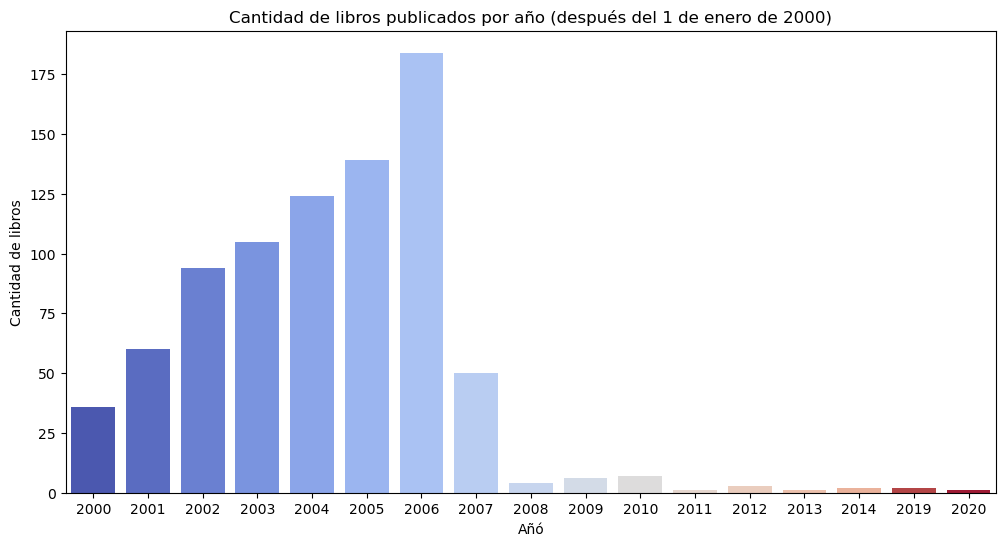

In [522]:

# Filtrado de libros publicados después del 1 de enero de el año 2000
books_after_2000=get_data('''SELECT *
                            FROM books 
                            WHERE publication_date > \'2000-01-01\';''')

books_after_2000['publication_year']= pd.to_datetime(books_after_2000['publication_date']).dt.year
books_count_year = books_after_2000['publication_year'].value_counts().sort_index()
books_count_year= books_count_year.rename_axis('Year').reset_index(name='Count')

# Visualización de la cantidad de libros publicados por año

plt.figure(figsize=(12,6))
sns.barplot(data=books_count_year,x='Year', y='Count', palette='coolwarm',hue='Year', legend=False)
plt.title('Cantidad de libros publicados por año (después del 1 de enero de 2000)')
plt.xlabel('Añó')
plt.ylabel('Cantidad de libros')
plt.show()




### Comentarios
- A partir del nuevo siglo dinde se efectua el filtrado se resalta la mayoria de los libros publicados, lo que indica un crecimiento significativo en la producción editorial en este periodo.
- La consulta realizada permite identificar la cantidad de libros publicados después del 1 de enero de 2000, donde se aprecia la publicacion de `819` nuevos libros. 
- Al apreciar el numero de lanzamientos de libros por año apartir de esta fecha, se tiene un comportamiento creciente casi lineal hasta el año 2006, donde se observa un aumento significativo en la cantidad de libros publicados. A partir de 2007, se observa una caida bastante significativa de mas de un 70% de las publicaciones, motivo por el cual se recomienda investigar las causas de esta disminución, ya que puede estar relacionada con cambios en la industria editorial, la aparición de nuevas plataformas digitales o cambios en las preferencias de los lectores. 

## Número de reseñas de usuarios y calificación promedio para cada libro.


In [523]:
# Consulta de número de reseñas de usuarios y calificación promedio para cada libro
reviews_summary = get_data('''SELECT books.book_id,
                            books.title,
                            COUNT(reviews.review_id) AS num_reviews,
                            AVG(ratings.rating) AS avg_rating
                            FROM books
                            LEFT JOIN reviews ON books.book_id = reviews.book_id
                            LEFT JoIN ratings ON books.book_id = ratings.book_id
                            GROUP BY books.book_id, books.title;''')

# Top 10 libros con más reseñas
top10_reviews=reviews_summary.sort_values(by='num_reviews', ascending=False).head(10).reset_index(drop=True)
print(top10_reviews)



   book_id                                              title  num_reviews  \
0      948                            Twilight (Twilight  #1)         1120   
1      750                The Hobbit  or There and Back Again          528   
2      673                             The Catcher in the Rye          516   
3      302  Harry Potter and the Prisoner of Azkaban (Harr...          492   
4      299  Harry Potter and the Chamber of Secrets (Harry...          480   
5       75               Angels & Demons (Robert Langdon  #1)          420   
6      301  Harry Potter and the Order of the Phoenix (Har...          375   
7      779  The Lightning Thief (Percy Jackson and the Oly...          372   
8      722  The Fellowship of the Ring (The Lord of the Ri...          370   
9       79                                        Animal Farm          370   

   avg_rating  
0    3.662500  
1    4.125000  
2    3.825581  
3    4.414634  
4    4.287500  
5    3.678571  
6    4.186667  
7    4.080645

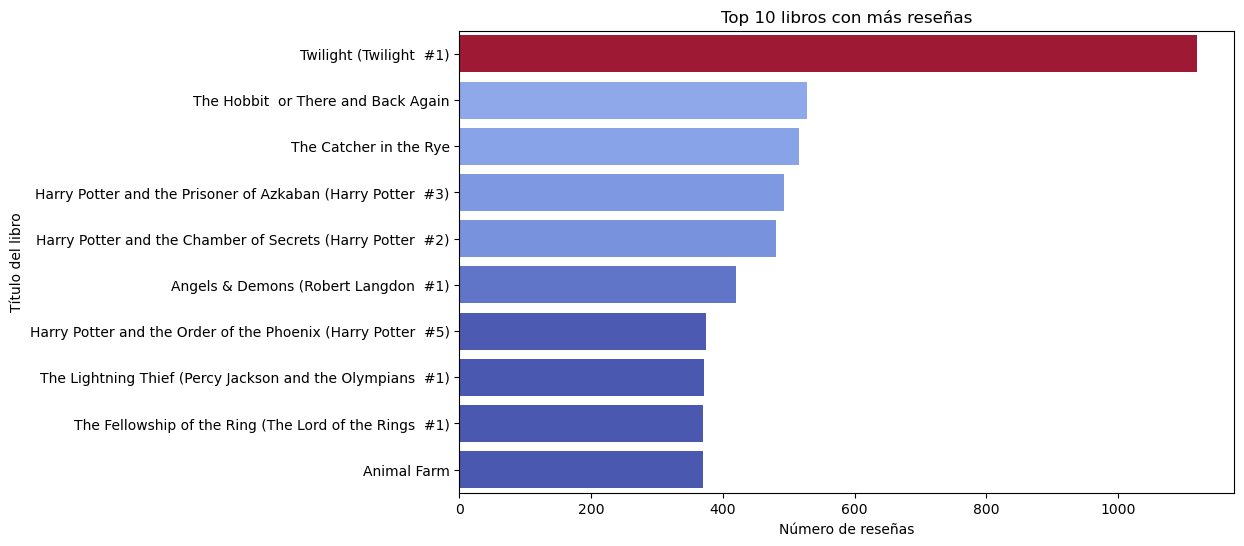

In [524]:
# Grafico Top 10 libros con más reseñas
plt.figure(figsize=(10,6))
sns.barplot(data=top10_reviews, x='num_reviews', y='title', palette='coolwarm', hue='num_reviews', legend=False)
plt.title('Top 10 libros con más reseñas')
plt.xlabel('Número de reseñas')
plt.ylabel('Título del libro')
plt.show()

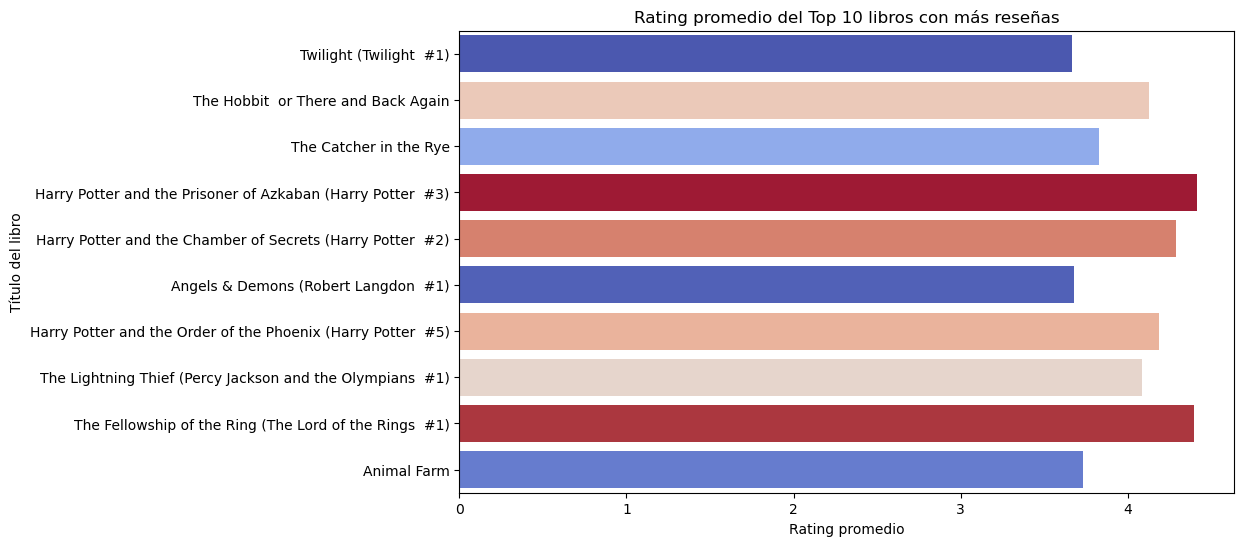

In [525]:
# Grafico de rating promedio del Top 10 libros con más reseñas
plt.figure(figsize=(10,6))
sns.barplot(data=top10_reviews, x='avg_rating', y='title', palette='coolwarm', hue='avg_rating', legend=False)
plt.title('Rating promedio del Top 10 libros con más reseñas')
plt.xlabel('Rating promedio')
plt.ylabel('Título del libro')
plt.show()

### Comentarios
- La consulta realizada permite identificar los libros con más reseñas y su calificación promedio, lo que proporciona una visión clara de la popularidad y la calidad de los libros en la plataforma.

- El análisis de los libros con más reseñas y su calificación promedio revela que los libros con mayor numero de reseñas tiende a tener una base estadstica solida, lo que sugiere una perpectiva clara de la calidad del libro.

- En primer lugar del top 10, se encuentra un libro con una cantidad de reseñas superior a 1000, con un claro liderazgo en el numero de reseñás, a partir de este libro, la cantidad de reseñas disminuye significativamente, con el segundo libro teniendo menos de 600 reseñas, la diferencia del top 3 en adelante apesar de ser clara no es lo suficientemente distante una de otra, Esto indica que hay un libro que destaca notablemente en términos de popularidad y participación de los usuarios.

- los libros presentes en el top 10, tienen una calificación promedio que varía entre 3.5 y 4.5, lo que indica que los usuarios tienden a calificar positivamente los libros que han leído y reseñado.


## Editorial que ha publicado el mayor número de libros con más de 50 páginas (Diferenciación Folletos y Libros)

In [528]:
# Consultas de libros publicados por editorial con más de 50 páginas
editorial_books = get_data('''SELECT publishers.publisher,
                            COUNT(books.book_id) AS num_books
                            FROM books
                            JOIN publishers ON books.publisher_id = publishers.publisher_id
                            WHERE books.num_pages > 50
                            GROUP BY publishers.publisher
                           ''')
top10_editorial = editorial_books.sort_values(by='num_books', ascending=False).head(10).reset_index(drop=True)
print(top10_editorial)

                   publisher  num_books
0              Penguin Books         42
1                    Vintage         31
2   Grand Central Publishing         25
3           Penguin Classics         24
4           Ballantine Books         19
5                     Bantam         19
6                    Berkley         17
7              Berkley Books         14
8         St. Martin's Press         14
9  William Morrow Paperbacks         13


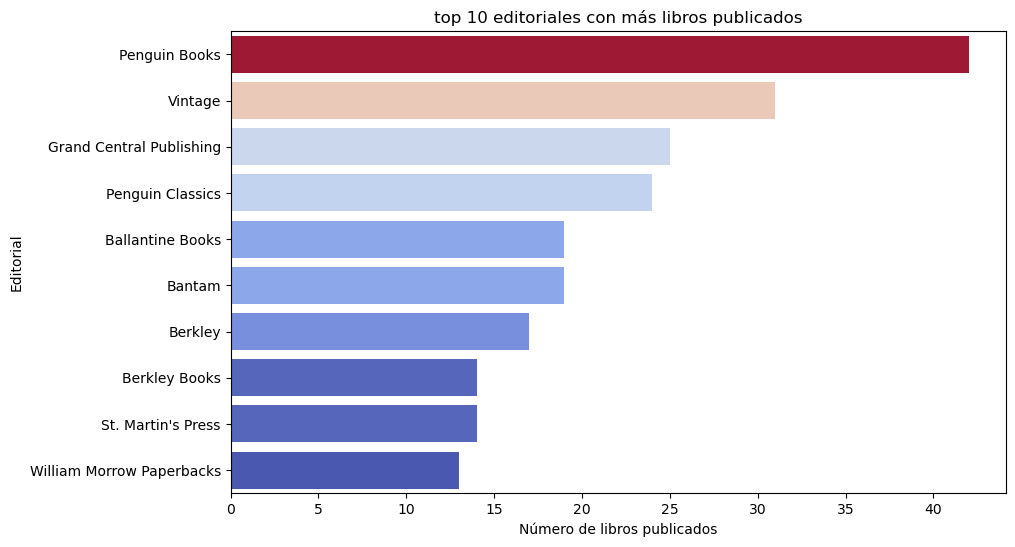

In [529]:
# Grafico top 10 editoriales con más libros publicados
plt.figure(figsize=(10,6))
sns.barplot(data=top10_editorial, x='num_books', y='publisher', palette='coolwarm', hue='num_books', legend=False)
plt.title('top 10 editoriales con más libros publicados')
plt.xlabel('Número de libros publicados')
plt.ylabel('Editorial')
plt.show()

### Comentarios

- Penguin Books destaca ampliamente como la editorial con mayor cantidad de libros publicados, superando por un margen considerable al resto de las editoriales del top 10 ello se suma que Penguin Books tiene direntes subdvisiones empresariales y una de ellas tambien se encuentra en el top 10.
- Vintage y Grand Central Publishing ocupan el segundo y tercer lugar respectivamente, pero con una diferencia notable respecto a Penguin Books, lo que indica una concentración significativa de publicaciones en la editorial líder.
- El resto de las editoriales, como Penguin Classics, Ballantine Books, Bantam y Berkley, presentan cifras similares entre sí, lo que sugiere una competencia más equilibrada en los puestos intermedios.
- La diferencia entre la editorial líder y las demás es considerable, lo que podría indicar una mayor capacidad de producción, catálogo más amplio o mayor presencia en el mercado por parte de Penguin Books.
- La diversidad de editoriales en el top 10 muestra que, aunque hay una editorial dominante, existe una oferta variada de publicaciones provenientes de diferentes casas editoriales, lo que puede enriquecer la experiencia de los lectores.
- Las editoriales en los últimos lugares del top 10 (como William Morrow Paperbacks y St. Martin’s Press) tienen una cantidad de libros publicados significativamente menor, lo que podría indicar un enfoque más especializado o menor volumen de publicaciones. 

## Autores con la calificación promedio más alta por libros 